In [2]:
import duckdb
import pandas as pd
from pathlib import Path
import numpy as np

class DataHubReader:
    def __init__(self, db_name="silver_company.db"):
        """
        Stellt Verbindung zur DuckDB her.
        Erwartet dieselbe Ordnerstruktur wie DataHub.
        """
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data"  / db_name

        if not db_path.exists():
            raise FileNotFoundError(f"Datenbank nicht gefunden: {db_path}")
        self.con = duckdb.connect(str(db_path))

    def _fetch_table(self, table_name: str) -> pd.DataFrame:
        """Generische Methode zum Laden einer Tabelle."""
        return self.con.execute(f"SELECT * FROM {table_name}").df()
    def sql_command(self, command):
        return self.con.execute(f'{command}').df()
    def get_prices(self):
        return self.con.execute(f'Select * from observations').df()
    def close(self):
        """Schließt die Datenbankverbindung."""
        self.con.close()

In [3]:
hub =  DataHubReader()
data = hub.sql_command("Select * from observations")
items =  hub.sql_command("Select * from items")
result = data.merge(items[["ItemID", "ItemCategory"]], on="ItemID", how="left")
fundamentals = result[result['ItemCategory'].isin(['balance_sheet', 'cashflow', 'income_statement'])]
fundamentals

,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName,ItemCategory
188,1168,960,4,2025-12-31,-2.310073e+10,USD,1288.HK,AccumulatedDepreciation,balance_sheet
189,1169,960,14,2025-12-31,5.667516e+11,USD,1288.HK,AvailableForSaleSecurities,balance_sheet
190,1170,960,23,2025-12-31,6.146039e+10,USD,1288.HK,CapitalStock,balance_sheet
191,1171,960,24,2025-12-31,5.734496e+11,USD,1288.HK,CashAndCashEquivalents,balance_sheet
192,1172,960,25,2025-12-31,7.971444e+11,USD,1288.HK,CashCashEquivalentsAndFederalFundsSold,balance_sheet
...,...,...,...,...,...,...,...,...,...
9790248,9790249,8061,333,2023-03-31,2.347414e+09,USD,WMS,TotalExpenses,income_statement
9790249,9790250,8061,337,2023-03-31,7.193100e+08,USD,WMS,TotalOperatingIncomeAsReported,income_statement
9790250,9790251,8061,340,2023-03-31,3.071121e+09,USD,WMS,TotalRevenue,income_statement
9790251,9790252,8061,342,2023-03-31,-6.348000e+06,USD,WMS,TotalUnusualItems,income_statement


In [5]:
fundamentals = fundamentals.copy()  # falls schon im Speicher, sonst hier dein Read-Statement

# Dtypes SOFORT optimieren, bevor irgendwas anderes passiert -> spart durchgehend Speicher
fundamentals["EntityCode"] = fundamentals["EntityCode"].astype("category")
fundamentals["ItemName"] = fundamentals["ItemName"].astype("category")
fundamentals["Date"] = pd.to_datetime(fundamentals["Date"])
fundamentals["YearMonth"] = fundamentals["Date"].dt.to_period("M")
total_companies = fundamentals["EntityCode"].nunique()

item_coverage = (
    fundamentals.groupby("ItemName", observed=True)["EntityCode"]  # observed=True wichtig bei category-dtype!
    .nunique()
    .rename("n_companies")
    .reset_index()
)
item_coverage["coverage_pct"] = item_coverage["n_companies"] / total_companies * 100
item_coverage = item_coverage.sort_values("coverage_pct", ascending=False).reset_index(drop=True)
# Threshold nach Sichtung der Verteilung oben festlegen
THRESHOLD_PCT = 70.0  # anpassen an deine tatsächliche Coverage-Verteilung

keep_items = item_coverage.loc[item_coverage["coverage_pct"] >= THRESHOLD_PCT, "ItemName"]
print(f"Behalte {len(keep_items)} von {item_coverage.shape[0]} Items ({len(keep_items)/item_coverage.shape[0]*100:.1f}%)")

fundamentals_filtered = fundamentals[fundamentals["ItemName"].isin(keep_items)].copy()

# category-dtype nach dem Filtern neu setzen, damit ungenutzte Kategorien nicht mitgeschleppt werden
fundamentals_filtered["ItemName"] = fundamentals_filtered["ItemName"].cat.remove_unused_categories()
fundamentals_filtered["EntityCode"] = fundamentals_filtered["EntityCode"].cat.remove_unused_categories()

print(fundamentals_filtered.shape, "vs. vorher", fundamentals.shape)
fundamentals_filtered

Behalte 110 von 348 Items (31.6%)
(3805532, 10) vs. vorher (6128609, 10)


,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName,ItemCategory,YearMonth
188,1168,960,4,2025-12-31,-2.310073e+10,USD,1288.HK,AccumulatedDepreciation,balance_sheet,2025-12
190,1170,960,23,2025-12-31,6.146039e+10,USD,1288.HK,CapitalStock,balance_sheet,2025-12
191,1171,960,24,2025-12-31,5.734496e+11,USD,1288.HK,CashAndCashEquivalents,balance_sheet,2025-12
195,1175,960,59,2025-12-31,5.002544e+10,USD,1288.HK,CommonStock,balance_sheet,2025-12
196,1176,960,61,2025-12-31,4.512774e+11,USD,1288.HK,CommonStockEquity,balance_sheet,2025-12
...,...,...,...,...,...,...,...,...,...,...
9790247,9790248,8061,325,2023-03-31,2.290000e-01,USD,WMS,TaxRateForCalcs,income_statement,2023-03
9790248,9790249,8061,333,2023-03-31,2.347414e+09,USD,WMS,TotalExpenses,income_statement,2023-03
9790250,9790251,8061,340,2023-03-31,3.071121e+09,USD,WMS,TotalRevenue,income_statement,2023-03
9790251,9790252,8061,342,2023-03-31,-6.348000e+06,USD,WMS,TotalUnusualItems,income_statement,2023-03


count    8120.000000
mean      754.754803
std       166.968516
min         4.000000
25%       668.000000
50%       790.000000
75%       865.000000
max      1308.000000
dtype: float64
EntityCode
FSDV.PA       4
BOT          17
PLGC.OL      26
XXI          33
NWAX         33
ALOY         36
MCHB         39
BRR          44
MLPHO.PA     57
MLHBP.PA     68
GAIN.MI      81
MLLOI.PA     85
GT.MI        99
MLARI.PA    102
MTK.MI      104
MLHBB.PA    106
FRMI        111
DTCX        122
ZSQR        126
CHRN        128
MLTV.BR     128
AMI.MI      130
MLGAL.PA    133
SDHI        136
MLONE.PA    148
NEWT.BR     154
GYRO        155
MLNMA.PA    156
MLMED.PA    156
IRHO        160
dtype: int64


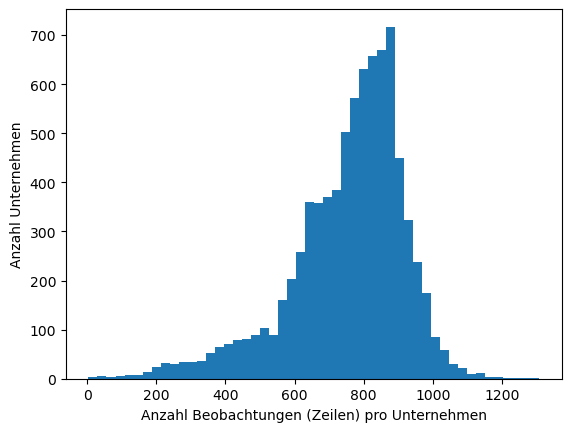

In [9]:
obs_per_company = fundamentals.groupby("EntityCode", observed=True).size().sort_values()
print(obs_per_company.describe())
print(obs_per_company.head(30))  # die "dünnsten" Unternehmen

# Verteilung anschauen
import matplotlib.pyplot as plt
plt.hist(obs_per_company, bins=50)
plt.xlabel("Anzahl Beobachtungen (Zeilen) pro Unternehmen")
plt.ylabel("Anzahl Unternehmen")
plt.show()

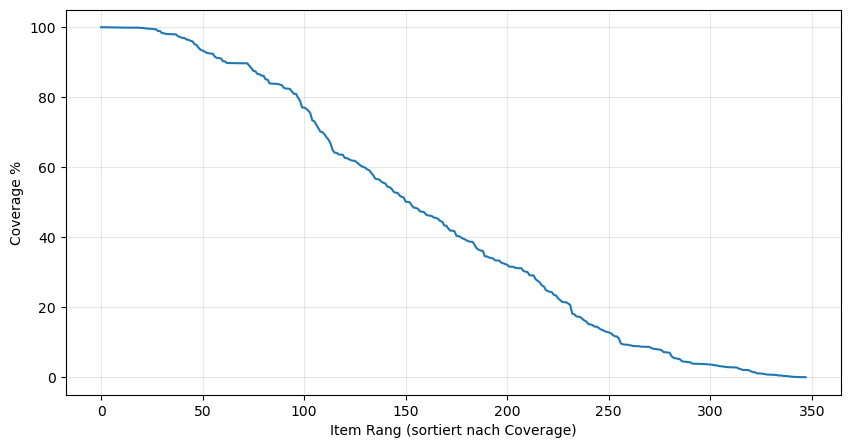

count    348.000000
mean      46.082081
std       35.616131
min        0.061576
25%        9.193350
50%       41.816502
75%       83.768473
max       99.950739
Name: coverage_pct, dtype: float64
5%-Quantil: 0.8%
10%-Quantil: 2.9%
25%-Quantil: 9.2%
50%-Quantil: 41.8%
75%-Quantil: 83.8%
90%-Quantil: 98.0%


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(item_coverage.index, item_coverage["coverage_pct"])
plt.xlabel("Item Rang (sortiert nach Coverage)")
plt.ylabel("Coverage %")
plt.grid(alpha=0.3)
plt.show()

# Zusätzlich: Quantile checken
print(item_coverage["coverage_pct"].describe())
for q in [0.05, 0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"{q*100:.0f}%-Quantil: {item_coverage['coverage_pct'].quantile(q):.1f}%")

In [7]:
pd.set_option('display.max_rows', None)
item_coverage

,ItemName,n_companies,coverage_pct
0,TotalEquityGrossMinorityInterest,8116,99.950739
1,TotalAssets,8115,99.938424
2,TotalLiabilitiesNetMinorityInterest,8113,99.913793
3,CommonStockEquity,8113,99.913793
4,StockholdersEquity,8112,99.901478
5,TaxEffectOfUnusualItems,8112,99.901478
6,NetTangibleAssets,8110,99.876847
7,TaxRateForCalcs,8110,99.876847
8,TangibleBookValue,8109,99.864532
9,TotalRevenue,8107,99.839901


In [32]:
fundamentals["Date"] = pd.to_datetime(fundamentals["Date"])
fundamentals["YearMonth"] = fundamentals["Date"].dt.to_period("M")
company_range = (fundamentals.groupby("EntityCode")["YearMonth"].agg(first_month="min", last_month="max"))
fundamentals

C:\Users\Konra\AppData\Local\Temp\ipykernel_26216\3042379918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fundamentals["Date"] = pd.to_datetime(fundamentals["Date"])
C:\Users\Konra\AppData\Local\Temp\ipykernel_26216\3042379918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fundamentals["YearMonth"] = fundamentals["Date"].dt.to_period("M")


,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName,ItemCategory,YearMonth
188,1168,960,4,2025-12-31,-2.310073e+10,USD,1288.HK,AccumulatedDepreciation,balance_sheet,2025-12
189,1169,960,14,2025-12-31,5.667516e+11,USD,1288.HK,AvailableForSaleSecurities,balance_sheet,2025-12
190,1170,960,23,2025-12-31,6.146039e+10,USD,1288.HK,CapitalStock,balance_sheet,2025-12
191,1171,960,24,2025-12-31,5.734496e+11,USD,1288.HK,CashAndCashEquivalents,balance_sheet,2025-12
192,1172,960,25,2025-12-31,7.971444e+11,USD,1288.HK,CashCashEquivalentsAndFederalFundsSold,balance_sheet,2025-12
...,...,...,...,...,...,...,...,...,...,...
9790248,9790249,8061,333,2023-03-31,2.347414e+09,USD,WMS,TotalExpenses,income_statement,2023-03
9790249,9790250,8061,337,2023-03-31,7.193100e+08,USD,WMS,TotalOperatingIncomeAsReported,income_statement,2023-03
9790250,9790251,8061,340,2023-03-31,3.071121e+09,USD,WMS,TotalRevenue,income_statement,2023-03
9790251,9790252,8061,342,2023-03-31,-6.348000e+06,USD,WMS,TotalUnusualItems,income_statement,2023-03


In [33]:
CURRENT_MONTH = pd.Period("2026-08", freq="M")

# 2. Cross-Product: jedes Unternehmen x jeder Monat in seiner aktiven Spanne x jedes Item,
#    das für dieses Unternehmen JEMALS vorkam (nicht global alle Items -> unnötig groß)
def build_panel(entity_code, items_for_entity, first_month, last_month):
    months = pd.period_range(first_month, min(last_month, CURRENT_MONTH), freq="M")
    idx = pd.MultiIndex.from_product([[entity_code], items_for_entity, months],
                                       names=["EntityCode", "ItemName", "YearMonth"])
    return pd.DataFrame(index=idx).reset_index()

items_per_entity = fundamentals.groupby("EntityCode")["ItemName"].unique()

panels = []
for entity_code, first_month in company_range["first_month"].items():
    last_month = company_range.loc[entity_code, "last_month"]
    panels.append(build_panel(entity_code, items_per_entity[entity_code], first_month, last_month))

full_panel = pd.concat(panels, ignore_index=True)
full_panel

,EntityCode,ItemName,YearMonth
0,0001.HK,AccountsPayable,2021-12
1,0001.HK,AccountsPayable,2022-01
2,0001.HK,AccountsPayable,2022-02
3,0001.HK,AccountsPayable,2022-03
4,0001.HK,AccountsPayable,2022-04
...,...,...,...
60591894,ZYME,TotalUnusualItemsExcludingGoodwill,2025-08
60591895,ZYME,TotalUnusualItemsExcludingGoodwill,2025-09
60591896,ZYME,TotalUnusualItemsExcludingGoodwill,2025-10
60591897,ZYME,TotalUnusualItemsExcludingGoodwill,2025-11


In [34]:
full_panel = full_panel.merge(
    fundamentals[["EntityCode", "ItemName", "YearMonth", "Value"]]
    .drop_duplicates(subset=["EntityCode", "ItemName", "YearMonth"]),  # falls mehrere Meldungen im selben Monat
    on=["EntityCode", "ItemName", "YearMonth"],
    how="left"
)
full_panel

,EntityCode,ItemName,YearMonth,Value
0,0001.HK,AccountsPayable,2021-12,NaN
1,0001.HK,AccountsPayable,2022-01,NaN
2,0001.HK,AccountsPayable,2022-02,NaN
3,0001.HK,AccountsPayable,2022-03,NaN
4,0001.HK,AccountsPayable,2022-04,NaN
...,...,...,...,...
60591894,ZYME,TotalUnusualItemsExcludingGoodwill,2025-08,NaN
60591895,ZYME,TotalUnusualItemsExcludingGoodwill,2025-09,NaN
60591896,ZYME,TotalUnusualItemsExcludingGoodwill,2025-10,NaN
60591897,ZYME,TotalUnusualItemsExcludingGoodwill,2025-11,NaN


In [35]:
full_panel

,EntityCode,ItemName,YearMonth,Value
0,0001.HK,AccountsPayable,2021-12,NaN
1,0001.HK,AccountsPayable,2022-01,NaN
2,0001.HK,AccountsPayable,2022-02,NaN
3,0001.HK,AccountsPayable,2022-03,NaN
4,0001.HK,AccountsPayable,2022-04,NaN
...,...,...,...,...
60591894,ZYME,TotalUnusualItemsExcludingGoodwill,2025-08,NaN
60591895,ZYME,TotalUnusualItemsExcludingGoodwill,2025-09,NaN
60591896,ZYME,TotalUnusualItemsExcludingGoodwill,2025-10,NaN
60591897,ZYME,TotalUnusualItemsExcludingGoodwill,2025-11,NaN


In [36]:
full_panel = full_panel.sort_values(["EntityCode", "ItemName", "YearMonth"])
full_panel["is_observed"] = full_panel["Value"].notna()
full_panel

,EntityCode,ItemName,YearMonth,Value,is_observed
0,0001.HK,AccountsPayable,2021-12,NaN,False
1,0001.HK,AccountsPayable,2022-01,NaN,False
2,0001.HK,AccountsPayable,2022-02,NaN,False
3,0001.HK,AccountsPayable,2022-03,NaN,False
4,0001.HK,AccountsPayable,2022-04,NaN,False
...,...,...,...,...,...
60586994,ZYME,WorkingCapital,2025-08,NaN,False
60586995,ZYME,WorkingCapital,2025-09,NaN,False
60586996,ZYME,WorkingCapital,2025-10,NaN,False
60586997,ZYME,WorkingCapital,2025-11,NaN,False


In [37]:
# 6. Erste jemals beobachtete Periode pro (EntityCode, ItemName)
first_obs = (
    full_panel[full_panel["is_observed"]]
    .groupby(["EntityCode", "ItemName"])["YearMonth"]
    .min()
    .rename("first_obs_month")
)
full_panel = full_panel.merge(first_obs, on=["EntityCode", "ItemName"], how="left")

# 7. Forward-Fill NUR ab der ersten Beobachtung (danach ist ffill sinnvoll)
full_panel["value_filled"] = full_panel.groupby(["EntityCode", "ItemName"])["Value"].ffill()

MemoryError: Unable to allocate 462. MiB for an array with shape (60591899,) and data type int64

In [ ]:
# 8. Drei-Zustände-Klassifikation
full_panel["status"] = np.select_kwargs = None  # Platzhalter, siehe np.select unten
conditions = [
    full_panel["is_observed"],                                    # original beobachtet
    full_panel["first_obs_month"].isna(),                         # Item wurde NIE beobachtet -> Typ B (strukturell)
    full_panel["YearMonth"] < full_panel["first_obs_month"],       # vor erster Beobachtung -> "noch nicht beobachtet"
]
choices = ["observed", "never_reported", "not_yet_observed"]
full_panel["status"] = np.select(conditions, choices, default="forward_filled")  # sonst: Typ A, forward-gefüllt

In [ ]:
full_panel

,EntityCode,ItemName,YearMonth,Value,is_observed,first_obs_month,value_filled,status
0,0001.HK,AccountsPayable,2021-12,NaN,False,2022-12,NaN,not_yet_observed
1,0001.HK,AccountsPayable,2022-01,NaN,False,2022-12,NaN,not_yet_observed
2,0001.HK,AccountsPayable,2022-02,NaN,False,2022-12,NaN,not_yet_observed
3,0001.HK,AccountsPayable,2022-03,NaN,False,2022-12,NaN,not_yet_observed
4,0001.HK,AccountsPayable,2022-04,NaN,False,2022-12,NaN,not_yet_observed
...,...,...,...,...,...,...,...,...
60591894,ZYME,WorkingCapital,2025-08,NaN,False,2022-12,212157000.0,forward_filled
60591895,ZYME,WorkingCapital,2025-09,NaN,False,2022-12,212157000.0,forward_filled
60591896,ZYME,WorkingCapital,2025-10,NaN,False,2022-12,212157000.0,forward_filled
60591897,ZYME,WorkingCapital,2025-11,NaN,False,2022-12,212157000.0,forward_filled


In [ ]:
# 1. Coverage berechnen: Anteil der Unternehmen, die dieses Item MINDESTENS EINMAL 
#    tatsächlich beobachtet haben (nicht forward-filled!)
total_companies = full_panel["EntityCode"].nunique()

item_coverage = (
    full_panel[full_panel["is_observed"]]  # nur echte Beobachtungen zählen, kein ffill
    .groupby("ItemName")["EntityCode"]
    .nunique()
    .rename("n_companies")
    .reset_index()
)
item_coverage["coverage_pct"] = item_coverage["n_companies"] / total_companies * 100

# 2. Threshold anwenden (Wert je nach deiner vorherigen Analyse der Verteilung wählen)
THRESHOLD_PCT = 70.0  # Beispielwert, an deine Coverage-Verteilung anpassen
keep_items = item_coverage.loc[item_coverage["coverage_pct"] >= THRESHOLD_PCT, "ItemName"]

print(f"Behalte {len(keep_items)} von {item_coverage.shape[0]} Items")

# 3. full_panel filtern
final_data = full_panel[full_panel["ItemName"].isin(keep_items)].reset_index(drop=True)

Behalte 97 von 97 Items


In [ ]:
full_panel

,EntityCode,ItemName,YearMonth,Value,is_observed,first_obs_month,value_filled,status
0,0001.HK,AccountsPayable,2021-12,NaN,False,2022-12,NaN,not_yet_observed
1,0001.HK,AccountsPayable,2022-01,NaN,False,2022-12,NaN,not_yet_observed
2,0001.HK,AccountsPayable,2022-02,NaN,False,2022-12,NaN,not_yet_observed
3,0001.HK,AccountsPayable,2022-03,NaN,False,2022-12,NaN,not_yet_observed
4,0001.HK,AccountsPayable,2022-04,NaN,False,2022-12,NaN,not_yet_observed
...,...,...,...,...,...,...,...,...
34020307,ZYME,WorkingCapital,2025-08,NaN,False,2022-12,212157000.0,forward_filled
34020308,ZYME,WorkingCapital,2025-09,NaN,False,2022-12,212157000.0,forward_filled
34020309,ZYME,WorkingCapital,2025-10,NaN,False,2022-12,212157000.0,forward_filled
34020310,ZYME,WorkingCapital,2025-11,NaN,False,2022-12,212157000.0,forward_filled


In [ ]:
total_companies = fundamentals['EntityCode'].nunique()
coverage = (
    fundamentals.groupby('ItemName')['EntityCode']
    .nunique()
    .reset_index()
    .rename(columns={'EntityCode': 'company_count'})
    .sort_values('company_count', ascending=False)
)
coverage['coverage_pct'] = coverage['company_count'] / total_companies * 100
usable_features = set(coverage[coverage['coverage_pct'] >= 85]['ItemName'])
print(len(usable_features))
print(usable_features)
#Für jeden EntityCode wird ein Set mit den vorhandenen ItemNames erstellt.
features_per_company = fundamentals.groupby('EntityCode')['ItemName'].apply(set)
#Erstellt ein DataFrame indem es quasi über alle EntityCodes iteriert und prüft ob mindestens die usable_features enthalten sind. Dann gibt es eine Liste von EntityCodes zurück für die die Prüfung True ist.
matching_companies = features_per_company[features_per_company.apply(lambda s: usable_features.issubset(s))].index.tolist()
print(f"Firmen mit mindestens diesen Features: {len(matching_companies)}")
#Hier werden aus dem Gesamtdaten DataFrame die EntityCodes extrahiert die in der matching_companies Liste enthalten sind.
comp_with_features = fundamentals[(fundamentals['EntityCode'].isin(matching_companies)) & (fundamentals['ItemName'].isin(usable_features))].copy()
coverage

82
{'AccountsPayable', 'TotalExpenses', 'NetInterestIncome', 'CashAndCashEquivalents', 'NetIncomeFromContinuingAndDiscontinuedOperation', 'TotalNonCurrentLiabilitiesNetMinorityInterest', 'CurrentDebtAndCapitalLeaseObligation', 'NetNonOperatingInterestIncomeExpense', 'OperatingCashFlow', 'TotalLiabilitiesNetMinorityInterest', 'NetIncome', 'CurrentLiabilities', 'NormalizedEBITDA', 'InvestingCashFlow', 'NetPPE', 'NetIncomeIncludingNoncontrollingInterests', 'TaxProvision', 'CashCashEquivalentsAndShortTermInvestments', 'NetTangibleAssets', 'TotalEquityGrossMinorityInterest', 'NetIncomeCommonStockholders', 'TaxRateForCalcs', 'TangibleBookValue', 'TotalCapitalization', 'CapitalStock', 'FreeCashFlow', 'DilutedAverageShares', 'AdditionalPaidInCapital', 'NetLongTermDebtIssuance', 'BasicEPS', 'EBITDA', 'DilutedNIAvailtoComStockholders', 'DepreciationAndAmortization', 'CommonStock', 'InvestedCapital', 'NetIssuancePaymentsOfDebt', 'Payables', 'ReconciledDepreciation', 'FinancingCashFlow', 'Accumula

,ItemName,company_count,coverage_pct
327,TotalEquityGrossMinorityInterest,8116,99.950739
324,TotalAssets,8115,99.938424
329,TotalLiabilitiesNetMinorityInterest,8113,99.913793
59,CommonStockEquity,8113,99.913793
316,StockholdersEquity,8112,99.901478
...,...,...,...
97,DividendsReceivedDirect,9,0.110837
39,ChangeInDividendPayable,8,0.098522
299,RestrictedCommonStock,8,0.098522
94,DividendsPaidDirect,7,0.086207


In [ ]:
coverage_by_year = (
    fundamentals
    .assign(Year=fundamentals["Date"].dt.year)  # Spaltenname ggf. anpassen
    .drop_duplicates(subset=["EntityCode", "ItemName", "Year"])
    .groupby(["ItemName", "Year"])["EntityCode"]
    .nunique()
    .unstack("Year")  # Jahre als Spalten nebeneinander
)
coverage_by_year_pct = coverage_by_year.div(fundamentals.groupby(fundamentals["Date"].dt.year)["EntityCode"].nunique(), axis=1) * 100
coverage_by_year_pct
# Jahre chronologisch sortieren, damit die Differenzenbildung stimmt
coverage_by_year_pct = coverage_by_year_pct.sort_index(axis=1)

# Differenz zum jeweiligen Vorjahr (in Prozentpunkten), Spalte für Spalte
coverage_diff = coverage_by_year_pct.diff(axis=1)

# Spalten umbenennen, damit klar ist, dass es sich um Diffs handelt
coverage_diff.columns = [f"{col}_diff" for col in coverage_diff.columns]

# Durchschnittliche absolute Abweichung über alle Jahre hinweg pro ItemName
# (abs(), weil dich vermutlich Schwankungen in beide Richtungen interessieren,
# nicht nur ob es im Schnitt netto rauf oder runter ging)
coverage_diff["avg_abs_diff"] = coverage_diff.filter(like="_diff").abs().mean(axis=1, skipna=True)

# Optional: auch die durchschnittliche NICHT-absolute Abweichung (zeigt Trendrichtung)
coverage_diff["avg_diff"] = coverage_diff.filter(like="_diff").drop(columns="avg_abs_diff").mean(axis=1, skipna=True)

# Alles zusammenführen: originale Coverage + Diffs nebeneinander
coverage_full = coverage_by_year_pct.join(coverage_diff)
coverage_full.sort_values("avg_abs_diff", ascending=False)
print("Unterschied 2022", coverage_full['2022_diff'].abs().mean())
print("Unterschied 2023", coverage_full['2023_diff'].abs().mean())
print("Unterschied 2024", coverage_full['2024_diff'].abs().mean())
print("Unterschied 2025", coverage_full['2025_diff'].abs().mean())

Unterschied 2022 2.7910705820040334
Unterschied 2023 0.20767328324373135
Unterschied 2024 0.1211805266102944
Unterschied 2025 0.6725221640172421


In [ ]:
companies_per_year = fundamentals.groupby(fundamentals["Date"].dt.year)["EntityCode"].nunique()
print(companies_per_year)

Date
2021    6884
2022    7882
2023    8029
2024    8021
2025    7644
2026     227
Name: EntityCode, dtype: int64


In [ ]:
# Erstes und letztes Beobachtungsjahr pro Unternehmen
company_year_range = (
    fundamentals[fundamentals["Date"].dt.year < 2026]
    .groupby("EntityCode")["Date"]
    .agg(first_year=lambda x: x.dt.year.min(), last_year=lambda x: x.dt.year.max())
)

# Unternehmen mit "Lücken in der Mitte" (z.B. 2021 und 2024 vorhanden, 2022/2023 nicht)
# das wäre ein Hinweis auf echte Datenqualitätsprobleme, nicht auf IPO/Delisting
years_present = fundamentals[fundamentals["Date"].dt.year < 2026].groupby("EntityCode")["Date"].apply(lambda x: set(x.dt.year))
company_year_range["expected_range"] = company_year_range.apply(lambda r: set(range(r["first_year"], r["last_year"]+1)), axis=1)
company_year_range["has_gap"] = [len(expected - present) > 0 for expected, present in zip(company_year_range["expected_range"], years_present)]

print(company_year_range["has_gap"].value_counts())

has_gap
False    8092
True       28
Name: count, dtype: int64


In [ ]:
gap_companies = company_year_range[company_year_range["has_gap"]]
print(gap_companies)

# Für ein paar Beispiele die tatsächlichen Jahre anschauen
for entity in gap_companies.index[:5]:
    print(entity, sorted(years_present[entity]))

            first_year  last_year                  expected_range  has_gap
EntityCode                                                                
0943.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
1116.HK           2021       2024        {2024, 2021, 2022, 2023}     True
1255.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
1372.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
1563.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
1676.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
1831.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
2371.HK           2021       2025  {2021, 2022, 2023, 2024, 2025}     True
AL2SI.PA          2022       2025        {2024, 2025, 2022, 2023}     True
ALETC.PA          2021       2025  {2021, 2022, 2023, 2024, 2025}     True
ALPWG.PA          2021       2025  {2021, 2022, 2023, 2024, 2025}     True
ALQWA.PA          2021   

In [ ]:
total_companies = fundamentals['EntityCode'].nunique()
coverage_2021_2022 = (
    fundamentals[fundamentals['Date'].dt.year.isin([2021, 2022])]
    .groupby('ItemName')['EntityCode']
    .nunique()
    .reset_index()
    .rename(columns={'EntityCode': 'company_count_2021_2022'})
)

coverage_2021_2022['coverage_pct_2021_2022'] = (
    coverage_2021_2022['company_count_2021_2022'] / total_companies * 100
)

coverage_2021_2022 = coverage_2021_2022.sort_values('coverage_pct_2021_2022', ascending=False)
usable_features = set(coverage_2021_2022[coverage_2021_2022['coverage_pct_2021_2022'] > 85])

In [ ]:
comp_with_features = (
    comp_with_features
    .sort_values('Date')  # oder eine andere sinnvolle Sortierung, z.B. nach 'ReportDate'/'FilingDate'
    .drop_duplicates(subset=['EntityCode', 'ItemName', 'Date'], keep='last')
)
# Die Ziel-Daten (Jahresenden)
target_dates = pd.to_datetime(['2021-12-31', '2022-12-31', '2023-12-31', '2024-12-31', '2025-12-31'])

# Alle eindeutigen (EntityCode, ItemName)-Kombinationen, die es geben soll
combos = comp_with_features[['EntityCode', 'ItemName']].drop_duplicates()

# Kreuzprodukt: jede Kombo x jedes Zieldatum
full_index = combos.merge(pd.DataFrame({'Date': target_dates}), how='cross')

print(len(full_index))  # sollte len(combos) * 5 sein
result = full_index.merge(
    comp_with_features,
    on=['EntityCode', 'ItemName', 'Date'],
    how='left'
)
print(len(result))  # sollte exakt len(combos) * 5 sein
result.groupby('Date').size()  # sollte für jedes Datum gleich viele Zeilen zeigen
print(result['Value'].isna().sum())  # Anzahl der neu entstandenen NaN-Zeilen
print("len combos", len(combos)*5)
result.groupby('Date').size() 

1165220
1165220
408481
len combos 1165220


Date
2021-12-31    233044
2022-12-31    233044
2023-12-31    233044
2024-12-31    233044
2025-12-31    233044
dtype: int64